# Completeness

In the early stages of processing an [instrumental catalogue](https://gemsciencetools.github.io/quakeT/contents/glossary.html#term-Instrumental-catalogue) for use in [Probabilistic Seismic Hazard Analysis (PSHA)](https://gemsciencetools.github.io/quakeT/contents/glossary.html#term-Probabilistic-Seismic-Hazard-Analysis-PSHA), it is necessary to determine the [magnitude completeness (Mc)](https://gemsciencetools.github.io/quakeT/contents/glossary.html#term-Magnitude-completeness-Mc) of the [earthquake catalogue](https://gemsciencetools.github.io/quakeT/contents/glossary.html#term-Earthquake-catalogue). Incomplete catalogues can introduce bias into earthquake recurrence models, which may significantly affect seismic hazard estimates at a site. Therefore, identifying Mc is an essential step in preparing input data for PSHA.

In this notebook, two catalogue completeness methodologies are presented: the Stepp (1971) method [[7]](references.html#ref-stepp-1972) and an iterative approach [[8]](references.html#ref-johnson-2026). The methodology for analysing catalogue completeness is implemented in the current version of the Modeller’s Toolkit [[1]](references.html#ref-weatherill-2014).

In [1]:
import os
import subprocess
import numpy as np
import shutil
from IPython.display import Image, display
from openquake.hmtk.parsers.catalogue.csv_catalogue_parser import CsvCatalogueParser
from openquake.hmtk.seismicity.completeness.comp_stepp_1971 import Stepp1971

## Stepp, 1971

This is one of the earliest analytical approaches to estimation of [magnitude completeness](https://gemsciencetools.github.io/quakeT/contents/glossary.html#term-Magnitude-completeness-Mc). It is based on estimators of the [seismicity rate](https://gemsciencetools.github.io/quakeT/contents/glossary.html#term-Seismicity-rate), identifying the completeness magnitude when the observed rate of earthquakes above Mc begins to deviate from the expected rate.

The analysis of Stepp (1971) is a coarse, but relatively robust, approach to estimating the temporal variation in completeness of a catalogue. It has been widely applied since its development. The accuracy of the Mc depends on the magnitude and time intervals considered, and a degree of judgement is often needed to determine the time at which the rate deviates from the expected values. It has tended to be applied to catalogues on a large scale and for relatively higher Mc.

In this section, you need an HMTK format earthquake catalogue including the necessary columns described [here](../../contents/data_formats.html). 

In [2]:
catalogue = CsvCatalogueParser("../data/cat_it.csv").read_file()

Catalogue Attribute source_cat is not a recognised catalogue key
Catalogue Attribute depth_orig is not a recognised catalogue key
Catalogue Attribute winGT_fs01 is not a recognised catalogue key
Catalogue Attribute winGK_fs01 is not a recognised catalogue key
Catalogue Attribute rb_rfact10 is not a recognised catalogue key
Catalogue Attribute rb_rfact20 is not a recognised catalogue key
Catalogue Attribute rb_rfact30 is not a recognised catalogue key
Catalogue Attribute Date is not a recognised catalogue key


To run the `Stepp1971` algorithm, the configuration parameters, described below, should be entered in the form of a dictionary, such as the example shown in the snippet below:
- **time_bin:** the size of the time window in years,
- **magnitude_bin:** the size of the magnitude bin,
- **increment_lock:** (optional) is used to ensure consistency in the results to avoid the Mc increasing for the latest intervals in the catalogue simply due to the variability associated with the short duration. `True` means the program will ensure that the completeness magnitude for shorter, more recent windows is less than or equal to that of older, longer windows. `False` is to show the apparent variability.

In [3]:
comp_config = {'magnitude_bin': 0.5,
               'time_bin': 5.,
               'increment_lock': True}

In [4]:
completeness_algorithm = Stepp1971()
completeness_table = completeness_algorithm.completeness(catalogue, comp_config)

print("Completeness Table (Year, Magnitude):")
print(completeness_table)

Completeness Table (Year, Magnitude):
[[1973.     3.5]
 [1959.     4. ]
 [1942.     4.5]
 [1835.     5. ]
 [1798.     5.5]
 [1672.     6. ]
 [1548.     6.5]
 [1548.     7. ]]


As shown in the resulting `completeness_table`, the completeness algorithm provides the temporal variation of completeness (in this case with `increment_lock` enabled) as a two-column table. The first column represents the completeness year, while the second column gives the central magnitude value of the corresponding magnitude bin.

## Jointly estimating completeness and MFD parameters for PSHA

Next, a new completeness methodology (in the preparation process by Johnson et al., 2026 [[8]](references.html#ref-johnson-2026)) is introduced. 

They develop a technique to simultaneously estimate $b$-values and time-magnitude completeness windows that relies upon one of two regularly made assumptions about event distributions in a study region: that the magnitudes in the catalogue follow a Gutenberg-Richter magnitude distribution and that the rate of events in time follows a Poisson distribution.

In this methodology, there are two supplementary techniques to determine completeness and [magnitude-frequency distribution (MFD)](https://gemsciencetools.github.io/quakeT/contents/glossary.html#term-MagnitudeFrequency-Distribution-MFD) parameters such that the two assumptions can trade-off. The two approaches are based on the same fundamental principles, but they differ in the metric used to determine the optimal combined solution. Their automated method enables users to choose multiple potential completeness magnitudes and corresponding years, while the final selection is determined by a statistical algorithm designed to satisfy a key principle of PSHA. However, if users already have reliable knowledge of the completeness characteristics of their catalogue, they can restrict the range of magnitudes and years considered.

In [5]:
current_dir = os.getcwd()
data_dir = os.path.abspath("../data")
catalogue = os.path.join(data_dir, "cat_it.csv")
config = os.path.join(data_dir, "examp_comp_config.toml")

output_dir = os.path.join("..", "output", "comp_out")
os.makedirs(output_dir, exist_ok=True)

# Change the working directory to the OUTPUT folder to save everything there
os.chdir(output_dir)

The `completeness_generate` function uses the completeness-related data provided in the [TOML configuration](https://gemsciencetools.github.io/quakeT/contents/data_formats.html#completeness-configuration) file. It first reads the defined `years` and `mags` values, which should be selected based on available knowledge of the catalogue and the periods during which completeness might have changed. In the initial step, the function generates all possible completeness windows from the provided years and magnitude values.

In [6]:
subprocess.run(f"oqm cat completeness_generate {config} .", shell=True)

INFO:numexpr.utils:NumExpr defaulting to 14 threads.


Total number of combinations : 823,543
Index of first magnitude     : 0
Number of vals per iteration : 8
[2020 2000 1980 1960 1940 1920 1905]
Total number selected        : 1,716
Saving completeness tables in: .
Time taken {}:  -3.1534200830010377


CompletedProcess(args='oqm cat completeness_generate /Users/fahrettinkuran/quakeT/openquake/quaket/data/examp_comp_config.toml .', returncode=0)

Once all possible completeness tables have been generated, the next step is to perform the analysis. The `completeness_analysis` function first verifies whether the catalogue is compatible with each completeness table, ensuring that completeness increases with time and that each bin contains a sufficient number of events. It then calculates the Gutenberg–Richter (GR) occurrence parameters, namely the $a$- and $b$-value.

To perform the completeness analysis, we specify the locations of the previously prepared catalogues along with an output directory where the completeness results will be stored. The optimal completeness is then selected according to a norm defined in the configuration file through the `optimization_criterion`. For each possible completeness window, the corresponding norm value is computed. In this example, the `optimize` criterion is used, which identifies the preferred completeness model by minimizing the difference between the observed and expected MFDs associated with the tested completeness windows.

It should be noted that this step can be computationally demanding. If the catalogue contains a large number of events and/or many completeness-window combinations are evaluated, the analysis may require several minutes to complete, and substantially longer for very large catalogues.

In [7]:
subprocess.run(f"oqm cat completeness_analysis {catalogue} {config} . . completeness_results", shell=True)

INFO:numexpr.utils:NumExpr defaulting to 14 threads.


Reading completeness data from: .
Catalogue Attribute source_cat is not a recognised catalogue key
Catalogue Attribute depth_orig is not a recognised catalogue key
Catalogue Attribute winGT_fs01 is not a recognised catalogue key
Catalogue Attribute winGK_fs01 is not a recognised catalogue key
Catalogue Attribute rb_rfact10 is not a recognised catalogue key
Catalogue Attribute rb_rfact20 is not a recognised catalogue key
Catalogue Attribute rb_rfact30 is not a recognised catalogue key
Catalogue Attribute Date is not a recognised catalogue key

SOURCE: it
Catalogue contains 2629 events equal or above 4.5
starting norm =  1
Iteration: 01715 norm: 2.492893e-03
Index of selected permutation : 677
Maximum annual rate for 4.5   : -1.0000
GR a and b                    : 6.1062 1.1233
Completeness:
 [[1980.     5. ]
 [1940.     6.5]
 [1905.     7. ]]
{'complete': 16, 'warning': 0, 'else': 64, 'early': 0}
Updated /Users/fahrettinkuran/quakeT/openquake/quaket/data/examp_comp_config.toml


CompletedProcess(args='oqm cat completeness_analysis /Users/fahrettinkuran/quakeT/openquake/quaket/data/cat_it.csv /Users/fahrettinkuran/quakeT/openquake/quaket/data/examp_comp_config.toml . . completeness_results', returncode=0)

It may also be useful to examine plots of event density over time together with the selected completeness model. Such plots can be generated with the `plot_completeness_data` function.

In [8]:
subprocess.run(f"oqm wkf plot_completeness_data {catalogue} {config} .", shell=True)

INFO:numexpr.utils:NumExpr defaulting to 14 threads.


Catalogue Attribute source_cat is not a recognised catalogue key
Catalogue Attribute depth_orig is not a recognised catalogue key
Catalogue Attribute winGT_fs01 is not a recognised catalogue key
Catalogue Attribute winGK_fs01 is not a recognised catalogue key
Catalogue Attribute rb_rfact10 is not a recognised catalogue key
Catalogue Attribute rb_rfact20 is not a recognised catalogue key
Catalogue Attribute rb_rfact30 is not a recognised catalogue key
Catalogue Attribute Date is not a recognised catalogue key
src_id: it  source specific completeness
[[1980.     5. ]
 [1940.     6.5]
 [1905.     7. ]]


CompletedProcess(args='oqm wkf plot_completeness_data /Users/fahrettinkuran/quakeT/openquake/quaket/data/cat_it.csv /Users/fahrettinkuran/quakeT/openquake/quaket/data/examp_comp_config.toml .', returncode=0)

Done! Saved to: ../output/comp_out/fig_mfd_it.png


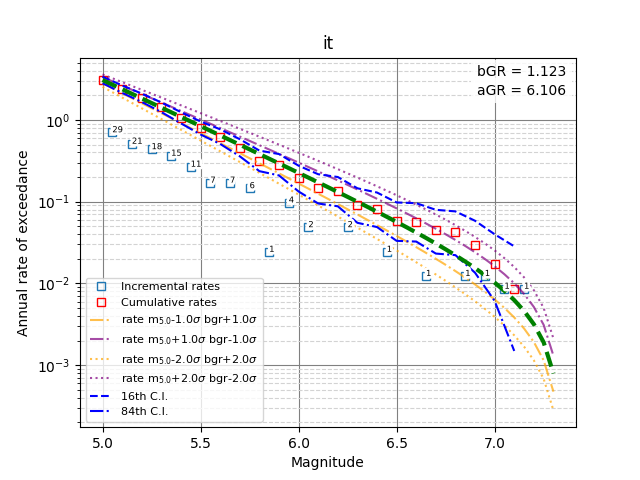

Done! Saved to: ../output/comp_out/fig_mtd_it.png


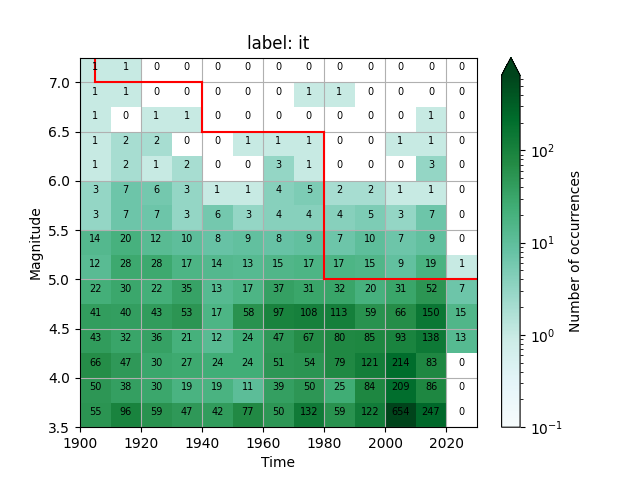

In [9]:
os.chdir(current_dir)

# Display Results
files = [f for f in os.listdir(output_dir) if f.endswith(".png")]
for f in files:
    img_path = os.path.join(output_dir, f)
    print(f"Done! Saved to: {img_path}")
    display(Image(filename=img_path))